### Declarations

In [1]:
from google.colab import files
files.upload()
print('Functions & packages imported')

Saving compiled_defs_RF_CHL_GON.ipynb to compiled_defs_RF_CHL_GON.ipynb
Functions & packages imported


In [2]:
import os
#os.remove("compiled_defs_RF_CHL_GON.ipynb")

In [3]:
!pip install mat73
!pip install netCDF4
!pip install windrose
!pip install gsw
!pip install seawater

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.7 MB/s eta 0:00:00


In [4]:
%run compiled_defs_RF_CHL_GON.ipynb

/tmp/ipykernel_12373/3134712253.py:16: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [5]:
import numpy as np
from scipy import stats
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error
)

def get_metrucs(A, P, ROUND=True, NR=3, PRINT=False):
    A = np.asarray(A, dtype=float).ravel()
    P = np.asarray(P, dtype=float).ravel()

    mask = np.isfinite(A) & np.isfinite(P)
    A = A[mask]
    P = P[mask]

    if len(A) < 3:
        return [np.nan] * 15

    MAE = mean_absolute_error(A, P)
    MEDAE = median_absolute_error(A, P)
    MAXE = np.nanmax(np.abs(A - P))
    MSE = mean_squared_error(A, P)
    RMSE = np.sqrt(MSE)

    if np.any(A == 0):
        MAPE = np.nan
    else:
        MAPE = mean_absolute_percentage_error(A, P)

    RSQU = r2_score(A, P)
    EXVA = explained_variance_score(A, P)

    PEAR, PEAV = stats.pearsonr(A, P)

    lin = stats.linregress(A, P)
    CF = lin.intercept
    SL = lin.slope
    SE = lin.stderr
    PV = lin.pvalue
    R2 = lin.rvalue ** 2

    vals = [MAE, MEDAE, MAXE, MSE, RMSE, MAPE,
            RSQU, EXVA, PEAR, PEAV, R2, PV, CF, SL, SE]

    if ROUND:
        vals = [np.round(v, NR) if np.isfinite(v) else np.nan for v in vals]

    if PRINT:
        print("Pearson:", vals[8])
        print("p-value:", vals[9])
        print("R2 score:", vals[6])
        print("Explained variance:", vals[7])
        print("MAE:", vals[0])
        print("MEDAE:", vals[1])
        print("RMSE:", vals[4])

    return vals

### Load Dataframe for ML

In [6]:
!rm -f df_FOR_ML_bgcTrue*.csv
!rm -f df_FOR_ML_bgcFalse*.csv

In [7]:
from google.colab import files
files.upload()
print('Dataframe loaded')

Saving df_FOR_ML_bgcFalse.csv to df_FOR_ML_bgcFalse.csv
Saving df_FOR_ML_bgcTrue.csv to df_FOR_ML_bgcTrue.csv
Dataframe loaded


In [8]:
import pandas as pd
WITH_BGC = False
df_FOR_ML = pd.read_csv('df_FOR_ML_bgc'+str(WITH_BGC)+'.csv')
d = df_FOR_ML.copy()
print('WITH_BGC',WITH_BGC,'\n',d.columns, d.shape)

WITH_BGC False 
 Index(['mc_mc', 'dates_mc', 'wy', 'dy', 'ts', 'dd', 'mm', 'yyyy', 'datetime',
       'timestamp', 'chl', 'P-E', 'Precip', 'CumPrecip', 'u', 'v', 'wdir',
       'uuvv', 'u1', 'v1', 'wdir1', 'uuvv1', 'u3', 'v3', 'wdir3', 'uuvv3',
       'sumu3', 'sumv3', 'sumuuvv3', 'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc',
       'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV',
       'CRI', 'FRWC', 'FP', 'FRSH', 'N1bulk', 'N1meanA', 'Tsurf', 'Sref',
       'Sbottom', 'SmaxSummer', 'Smodel0', 'Smodel00', 'Smodel1', 'Smodel11',
       'Smodel2', 'Smodel22', 'Smodel3', 'Smodel33', 'Smodel4', 'Smodel44',
       'Smodel5', 'Smodel55', 'Smodel6', 'Smodel66', 'Smodel7', 'Smodel77',
       'Smodel1_fp', 'Smodel11_fp', 'Smodel2_fp', 'Smodel22_fp', 'Smodel3_fp',
       'Smodel33_fp', 'Smodel4_fp', 'Smodel44_fp', 'Smodel5_fp', 'Smodel55_fp',
       'Smodel6_fp', 'Smodel66_fp', 'Smodel7_fp', 'Smodel77_fp', 'Ssurface',
       'Tsurface', 'FW', 'FR', 'chl10', 'season'],
      dtype

In [9]:
feats_list_raw = [
    'wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime',
    'chl', 'chl10',
    'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR',
    'BIGV', 'CRI', 'FW', 'FR', 'FP',
    'u', 'v', 'wdir', 'uuvv',
    'u3', 'v3', 'wdir3', 'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3',
    'u1', 'v1', 'wdir1', 'uuvv1',
    'P-E', 'Precip', 'CumPrecip',
    'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc',
    'SmaxSummer','Sbottom', 'Ssurface', 'Tsurface',
    'N1meanA', 'N1bulk'
]

feats_list_bgc= [
    'doxy', 'amon', 'ntra', 'ntri', 'dino', 'phos', 'slca', 'dino+0.5chl','ntri+0.5chl', 'ntra+0.5chl',
    'doxy10', 'amon10', 'ntra10', 'ntri10', 'dino10', 'phos10', 'slca10', 'dino+0.5chl10','ntri+0.5chl10', 'ntra+0.5chl10'
    ]

if WITH_BGC == True :
  feats_list_raw = feats_list_raw + feats_list_bgc


# remove duplicates while preserving order
feats_list = list(dict.fromkeys(feats_list_raw))

label_stri = 'chl10'

# checks
missing_feats = [c for c in feats_list if c not in d.columns]
missing_label = label_stri not in d.columns

print("Missing feats:", missing_feats)
print("Missing label:", missing_label)

# build dataframes
feats = d[feats_list].copy()
label = d[[label_stri]].copy()

feats.insert(len(feats.columns), 'index', np.arange(len(feats)).astype(int))

print(feats.shape)
print(list(feats.columns))
print('\nlabel:', label_stri, label.shape)

Missing feats: []
Missing label: False
(839, 47)
['wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime', 'chl', 'chl10', 'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV', 'CRI', 'FW', 'FR', 'FP', 'u', 'v', 'wdir', 'uuvv', 'u3', 'v3', 'wdir3', 'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3', 'u1', 'v1', 'wdir1', 'uuvv1', 'P-E', 'Precip', 'CumPrecip', 'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc', 'SmaxSummer', 'Sbottom', 'Ssurface', 'Tsurface', 'N1meanA', 'N1bulk', 'index']

label: chl10 (839, 1)


In [10]:
rename_dict = {
    'chl': 'CHL',
    'chl10': 'log10(CHL)',
    'LE': 'LE',
    'LE_STAR': 'LEclim',
    'SmaxSummer': 'S+',
    'Ssurface': 'S',
    'Tsurface': 'T',
    'uuvv': '|U|',
    'wdir': 'WD',
    'PREC_cmcc':'P',

    'doxy': 'DOXY',
    'amon': 'AMON',
    'ntra': 'NTRA',
    'ntri': 'NTRI',
    'dino': 'DINO',
    'phos': 'PHOS',
    'slca': 'SLCA',
    'dino+0.5chl': 'DINO+0.5CHL',
    'ntri+0.5chl': 'NTRI+0.5CHL',
    'ntra+0.5chl': 'NTRA+0.5CHL',

    'doxy10': 'log10(DOXY)',
    'amon10': 'log10(AMON)',
    'ntra10': 'log10(NTRA)',
    'ntri10': 'log10(NTRI)',
    'dino10': 'log10(DINO)',
    'phos10': 'log10(PHOS)',
    'slca10': 'log10(SLCA)',
    'dino+0.5chl10': 'log10(DINO+0.5CHL)',
    'ntri+0.5chl10': 'log10(NTRI+0.5CHL)',
    'ntra+0.5chl10': 'log10(NTRA+0.5CHL)',

}

missing = [k for k in rename_dict if k not in feats.columns]
if len(missing) > 0:
    print("Warning missing columns:", missing)

feats = feats.rename(columns=rename_dict)
feats_list = list(feats.columns)
print("Renamed columns OK")

Warning missing columns: ['doxy', 'amon', 'ntra', 'ntri', 'dino', 'phos', 'slca', 'dino+0.5chl', 'ntri+0.5chl', 'ntra+0.5chl', 'doxy10', 'amon10', 'ntra10', 'ntri10', 'dino10', 'phos10', 'slca10', 'dino+0.5chl10', 'ntri+0.5chl10', 'ntra+0.5chl10']
Renamed columns OK


### Correlations BGC/CHL with S,Freshs

In [13]:
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
from google.colab import files

d_in = feats.copy()
if "season" not in d_in.columns:
    d_in["season"] = d.loc[d_in.index, "season"].values ### cherche seasons dans d


testname = "REVIEW_Variance_FreshS"
#testname = "REVIEW_Variance_SvsFreshs"


nutrients = [
    "log10(CHL)",
    "log10(DINO)",
    "log10(NTRA)",
    "log10(DINO+0.5CHL)",
    "log10(NTRA+0.5CHL)"
]

nutrients = [
    "CHL",
    "DINO",
    "NTRA",
    "DINO+0.5CHL",
    "NTRA+0.5CHL"
]

metric = "R2"
use_pfilter = True
p_thresh = 10

#nutrients = [
#    "S",]

def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    x = x.where(x > 0)
    return np.log10(x)

def compute_stats_local(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    f = np.isfinite(x) & np.isfinite(y)
    if f.sum() < 3:
        return np.nan, np.nan, np.nan
    cc, pval = stats.pearsonr(x[f], y[f])
    return cc, cc**2, pval

def select_metric_local(cc, r2, pval, metric="R2", use_pfilter=True, p_thresh=0.01):
    if use_pfilter and np.isfinite(pval) and pval > p_thresh:
        return np.nan
    if metric == "R2":
        return r2
    if metric == "cc":
        return cc
    if metric == "pval":
        return pval
    raise ValueError("metric must be R2, cc, or pval")

def format_value_local(v, metric="R2"):
    if not np.isfinite(v):
        return ""
    if metric == "pval":
        return f"{v:.1e}"
    return f"{v:.3f}"



seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]
predictor_names = ["S", "FW", "FR", "FP", "FW/MLD", "FR/MLD", "FP/MLD"]



required = ["season", "MLD", "S", "FW", "FR", "FP"] + nutrients
missing_cols = [c for c in required if c not in d_in.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
    print("Available close columns:")
    print([c for c in d_in.columns if any(k.lower() in c.lower() for k in ["chl", "din", "dino", "ntri", "ntra", "nit"])])
    raise KeyError(missing_cols)

rows = []

for season in seasons:

    d_work = d_in.copy() if season == "ALL" else d_in[d_in["season"] == season].copy()

    mld = np.asarray(d_work["MLD"], dtype=float)
    fw = np.asarray(d_work["FW"], dtype=float)
    fr = np.asarray(d_work["FR"], dtype=float)
    fp = np.asarray(d_work["FP"], dtype=float)

    predictors = {
        "S": np.asarray(d_work["S"], dtype=float),
        "FW": fw,
        "FR": fr,
        "FP": fp,
        "FW/MLD": np.where((mld != 0) & np.isfinite(mld), fw / mld, np.nan),
        "FR/MLD": np.where((mld != 0) & np.isfinite(mld), fr / mld, np.nan),
        "FP/MLD": np.where((mld != 0) & np.isfinite(mld), fp / mld, np.nan),
    }

    for nut in nutrients:
        y = np.asarray(d_work[nut], dtype=float)

        row = {"season": season, "target": nut}

        for pred in predictor_names:
            cc, r2, pval = compute_stats_local(predictors[pred], y)
            row[pred] = select_metric_local(cc, r2, pval, metric, use_pfilter, p_thresh)

        rows.append(row)

df_out = pd.DataFrame(rows)
df_out = df_out[["season", "target"] + predictor_names]

df_out_fmt = df_out.copy()
for col in predictor_names:
    df_out_fmt[col] = df_out[col].apply(lambda v: format_value_local(v, metric))

display(df_out_fmt)

testname = testname + '_' + metric

csv_name = testname + ".csv"
xlsx_name = testname + ".xlsx"

df_out_fmt.to_csv(csv_name, index=False)
df_out_fmt.to_excel(xlsx_name, index=False)

files.download(csv_name)
files.download(xlsx_name)

,season,target,S,FW,FR,FP,FW/MLD,FR/MLD,FP/MLD
0,ALL,CHL,0.248,0.014,0.000,0.009,0.176,0.121,0.043
1,ALL,DINO,0.051,0.015,0.079,0.048,0.028,0.094,0.077
2,ALL,NTRA,0.092,0.015,0.104,0.059,0.041,0.135,0.099
3,ALL,DINO+0.5CHL,0.135,0.022,0.059,0.026,0.083,0.151,0.099
4,ALL,NTRA+0.5CHL,0.255,0.024,0.049,0.014,0.150,0.215,0.119
5,DJF,CHL,0.325,0.000,0.007,0.033,0.214,0.215,0.096
6,DJF,DINO,0.280,0.000,0.007,0.005,0.177,0.233,0.138
7,DJF,NTRA,0.513,0.001,0.007,0.013,0.256,0.482,0.407
8,DJF,DINO+0.5CHL,0.328,0.000,0.008,0.008,0.208,0.264,0.151
9,DJF,NTRA+0.5CHL,0.558,0.001,0.003,0.002,0.295,0.492,0.379


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

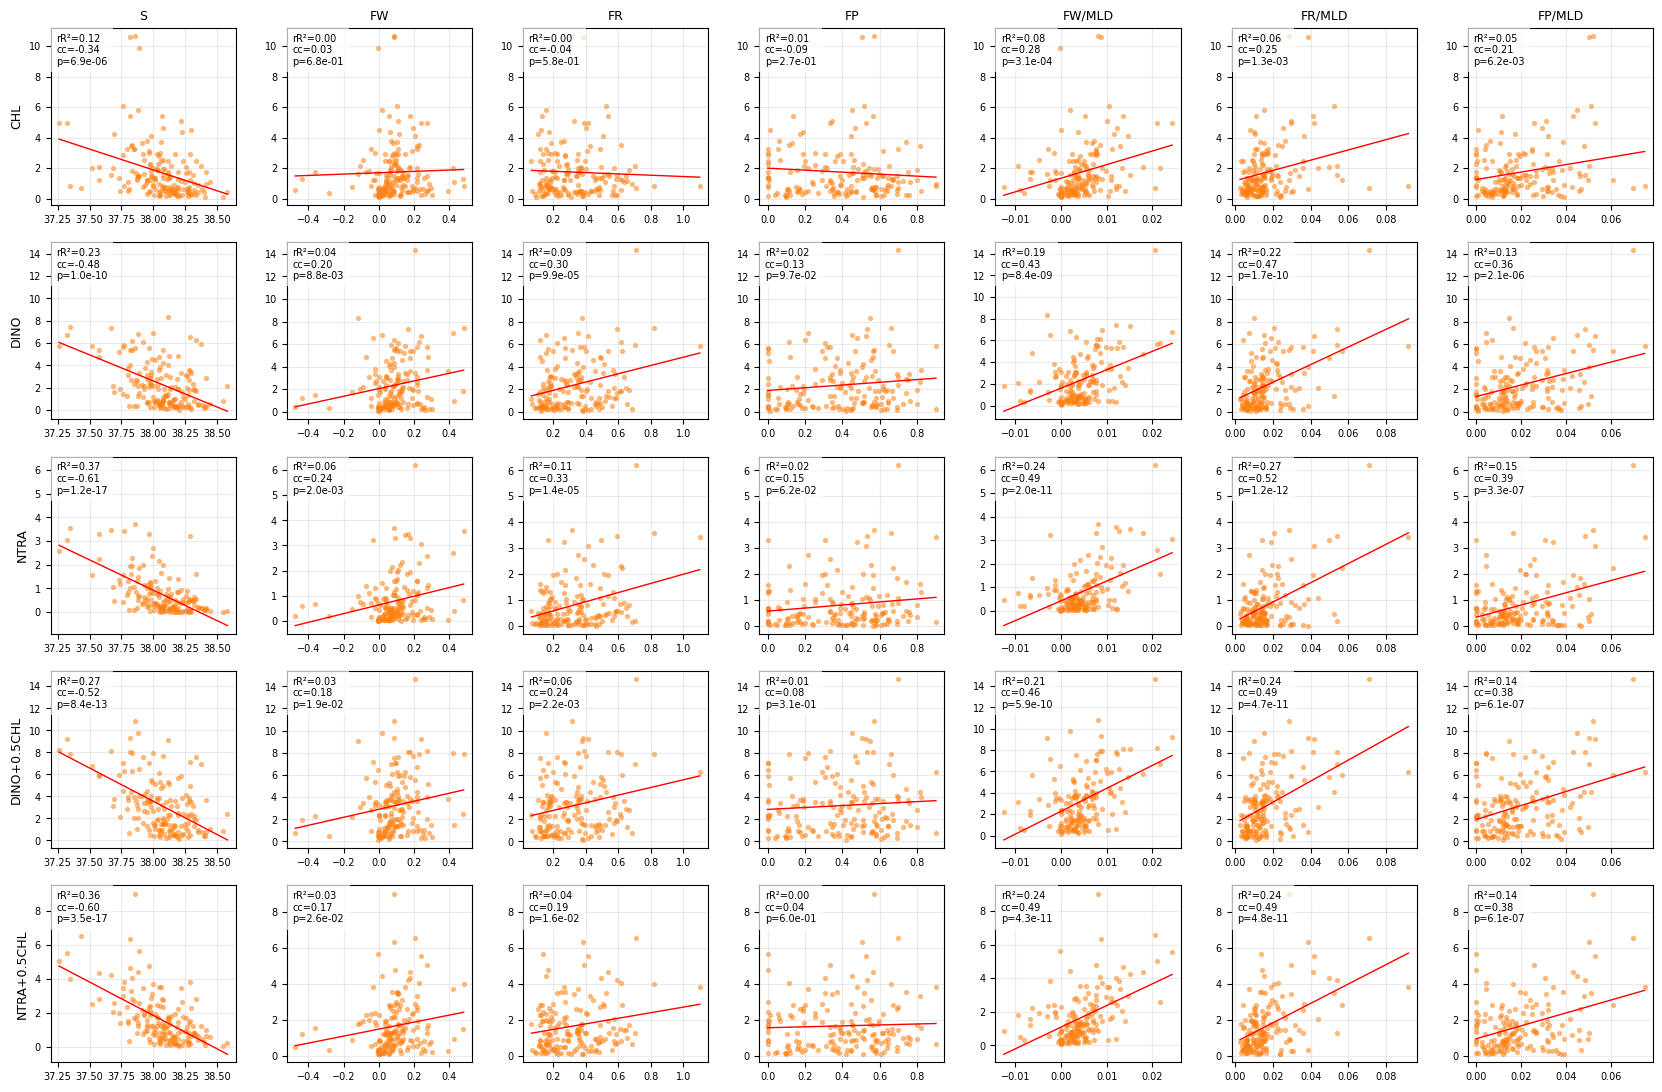

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
season_colors = {
    "ALL": "k",
    "DJF": "#1f77b4",   # blue
    "MAM": "#2ca02c",   # green
    "JJA": "#d62728",   # red
    "SON": "#ff7f0e",   # orange
    "winter": "#1f77b4",
    "spring": "#2ca02c",
    "summer": "#d62728",
    "autumn": "#ff7f0e"
}



import matplotlib.pyplot as plt
import math

scatter_season = "SON"
scatter_alpha = 0.45
scatter_color = "k"

if scatter_season == "ALL":
    d_scatter = d_in.copy()
else:
    d_scatter = d_in[d_in["season"] == scatter_season].copy()

sc_color = season_colors.get(scatter_season, "0.5")

mld = np.asarray(d_scatter["MLD"], dtype=float)
fw = np.asarray(d_scatter["FW"], dtype=float)
fr = np.asarray(d_scatter["FR"], dtype=float)
fp = np.asarray(d_scatter["FP"], dtype=float)

scatter_predictors = {
    "S": np.asarray(d_scatter["S"], dtype=float),
    "FW": fw,
    "FR": fr,
    "FP": fp,
    "FW/MLD": np.where((mld != 0) & np.isfinite(mld), fw / mld, np.nan),
    "FR/MLD": np.where((mld != 0) & np.isfinite(mld), fr / mld, np.nan),
    "FP/MLD": np.where((mld != 0) & np.isfinite(mld), fp / mld, np.nan),
}

nrows = len(nutrients)
ncols = len(predictor_names)

fig, axs = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.2 * nrows), squeeze=False)

for i, nut in enumerate(nutrients):

    y = np.asarray(d_scatter[nut], dtype=float)

    for j, pred in enumerate(predictor_names):

        ax = axs[i, j]
        x = scatter_predictors[pred]

        f = np.isfinite(x) & np.isfinite(y)
        xx = x[f]
        yy = y[f]

        ax.scatter(xx, yy, s=8, alpha=scatter_alpha, color=sc_color)

        if len(xx) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(xx, yy)
            xfit = np.linspace(np.nanmin(xx), np.nanmax(xx), 100)
            yfit = slope * xfit + intercept
            ax.plot(xfit, yfit, color="red", lw=1)
            ccvalue = np.corrcoef(xx, yy)[0,1]

            txt = f"rR²={r_value**2:.2f}\ncc={ccvalue:.2f}\np={p_value:.1e}"
            ax.text(
                0.03, 0.97, txt,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=7,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
            )

        if i == 0:
            ax.set_title(pred, fontsize=9)

        if j == 0:
            ax.set_ylabel(nut, fontsize=9)

        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=7)

fig.tight_layout(pad=1)

scatter_fig_name = testname + "_scatter_matrix_" + scatter_season + ".png"
fig.savefig(scatter_fig_name, dpi=600, bbox_inches="tight")
plt.show()

files.download(scatter_fig_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
from google.colab import files

d_in = feats.copy()
if "season" not in d_in.columns:
    d_in["season"] = d.loc[d_in.index, "season"].values

testname = "REVIEW_Variance_FreshS_LAG"

nutrients = [
    "CHL",
    "DINO",
    "NTRA",
    "DINO+0.5CHL",
    "NTRA+0.5CHL"
]

seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]
predictor_names = ["S", "FW", "FR", "FP", "FW/MLD", "FR/MLD", "FP/MLD"]

metric_select = "R2"
metric_show = "R2"
max_lag = 6

use_pfilter = True
p_thresh = 0.01

show_pval = False
show_lag = True

def compute_stats_lag(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    f = np.isfinite(x) & np.isfinite(y)
    x = x[f]
    y = y[f]

    if len(x) < 5:
        return np.nan, np.nan, np.nan

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return r_value, r_value**2, p_value

def get_metric_value(cc, r2, pval, which):
    if which == "R2":
        return r2
    if which == "cc":
        return cc
    if which == "pval":
        return pval
    return np.nan

def best_lag_stats(x, y, max_lag=12, metric_select="R2"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    best_score = np.inf if metric_select == "pval" else -np.inf
    best_lag = np.nan
    best_cc = np.nan
    best_r2 = np.nan
    best_pval = np.nan

    for lag in range(-max_lag, max_lag + 1):

        if lag > 0:
            xx = x[:-lag]
            yy = y[lag:]
        elif lag < 0:
            xx = x[-lag:]
            yy = y[:lag]
        else:
            xx = x
            yy = y

        cc, r2, pval = compute_stats_lag(xx, yy)
        score = get_metric_value(cc, r2, pval, metric_select)

        if metric_select == "pval":
            is_better = np.isfinite(score) and score < best_score
        else:
            is_better = np.isfinite(score) and score > best_score

        if is_better:
            best_score = score
            best_lag = lag
            best_cc = cc
            best_r2 = r2
            best_pval = pval

    return best_cc, best_r2, best_pval, best_lag

required = ["season", "MLD", "S", "FW", "FR", "FP"] + nutrients
missing_cols = [c for c in required if c not in d_in.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
    print("Available close columns:")
    print([c for c in d_in.columns if any(k.lower() in c.lower() for k in ["chl", "din", "dino", "ntra", "nit"])])
    raise KeyError(missing_cols)

rows = []

for season in seasons:

    d_work = d_in.copy() if season == "ALL" else d_in[d_in["season"] == season].copy()

    mld = np.asarray(d_work["MLD"], dtype=float)
    fw = np.asarray(d_work["FW"], dtype=float)
    fr = np.asarray(d_work["FR"], dtype=float)
    fp = np.asarray(d_work["FP"], dtype=float)

    predictors = {
        "S": np.asarray(d_work["S"], dtype=float),
        "FW": fw,
        "FR": fr,
        "FP": fp,
        "FW/MLD": np.where((mld != 0) & np.isfinite(mld), fw / mld, np.nan),
        "FR/MLD": np.where((mld != 0) & np.isfinite(mld), fr / mld, np.nan),
        "FP/MLD": np.where((mld != 0) & np.isfinite(mld), fp / mld, np.nan),
    }

    for nut in nutrients:

        y = np.asarray(d_work[nut], dtype=float)
        row = {"season": season, "target": nut}

        for pred in predictor_names:

            cc, r2, pval, lag = best_lag_stats(
                predictors[pred],
                y,
                max_lag=max_lag,
                metric_select=metric_select
            )

            val = get_metric_value(cc, r2, pval, metric_show)

            if use_pfilter and (not np.isfinite(pval) or pval > p_thresh):
                row[pred] = ""
            elif not np.isfinite(val):
                row[pred] = ""
            else:
                txt = f"{val:.3f}"
                if show_pval:
                    txt += f" (p={pval:.2e})"
                if show_lag:
                    txt += f" (lag={lag:+.0f})"
                row[pred] = txt

        rows.append(row)

df_lag = pd.DataFrame(rows)
df_lag = df_lag[["season", "target"] + predictor_names]

display(df_lag)

csv_name = testname + ".csv"
xlsx_name = testname + ".xlsx"

df_lag.to_csv(csv_name, index=False)
df_lag.to_excel(xlsx_name, index=False)

files.download(csv_name)
files.download(xlsx_name)

,season,target,S,FW,FR,FP,FW/MLD,FR/MLD,FP/MLD
0,ALL,CHL,0.248 (lag=+0),0.014 (lag=+0),0.024 (lag=-5),0.027 (lag=-5),0.176 (lag=+0),0.121 (lag=+0),0.047 (lag=+2)
1,ALL,DINO,0.056 (lag=-6),0.026 (lag=-5),0.082 (lag=-1),0.048 (lag=+0),0.062 (lag=-6),0.094 (lag=+0),0.077 (lag=+0)
2,ALL,NTRA,0.092 (lag=+0),0.018 (lag=-2),0.104 (lag=+0),0.059 (lag=+0),0.054 (lag=-6),0.135 (lag=+0),0.099 (lag=+0)
3,ALL,DINO+0.5CHL,0.135 (lag=+0),0.022 (lag=+0),0.059 (lag=+0),0.026 (lag=+0),0.083 (lag=+0),0.151 (lag=+0),0.099 (lag=+0)
4,ALL,NTRA+0.5CHL,0.255 (lag=+0),0.024 (lag=+0),0.055 (lag=+3),0.017 (lag=+5),0.150 (lag=+0),0.215 (lag=+0),0.119 (lag=+0)
5,DJF,CHL,0.325 (lag=+0),,,,0.214 (lag=+0),0.215 (lag=+0),0.096 (lag=+0)
6,DJF,DINO,0.280 (lag=+0),,,,0.177 (lag=+0),0.233 (lag=+0),0.138 (lag=+0)
7,DJF,NTRA,0.513 (lag=+0),,,,0.256 (lag=+0),0.482 (lag=+0),0.407 (lag=+0)
8,DJF,DINO+0.5CHL,0.328 (lag=+0),,,,0.208 (lag=+0),0.264 (lag=+0),0.151 (lag=+0)
9,DJF,NTRA+0.5CHL,0.558 (lag=+0),,,,0.295 (lag=+0),0.492 (lag=+0),0.379 (lag=+0)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

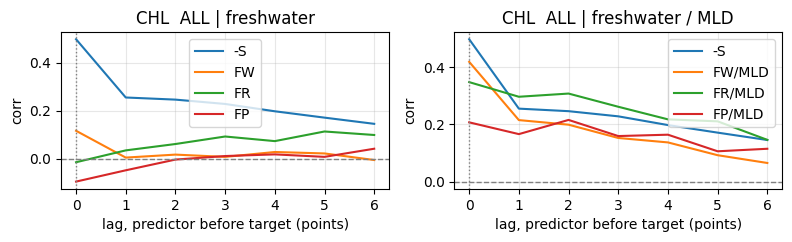

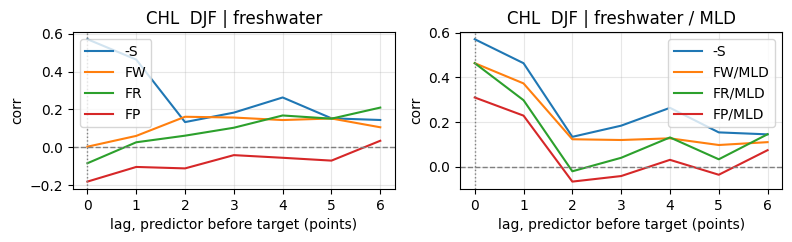

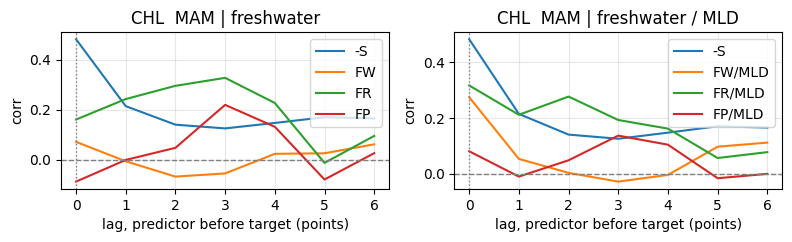

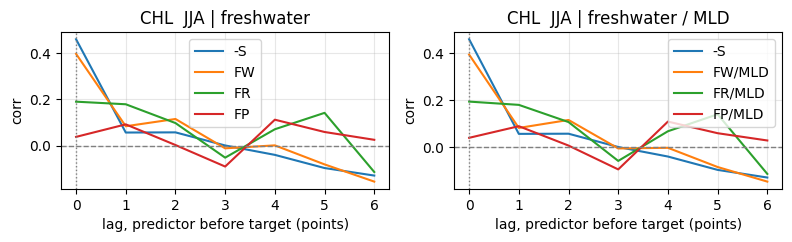

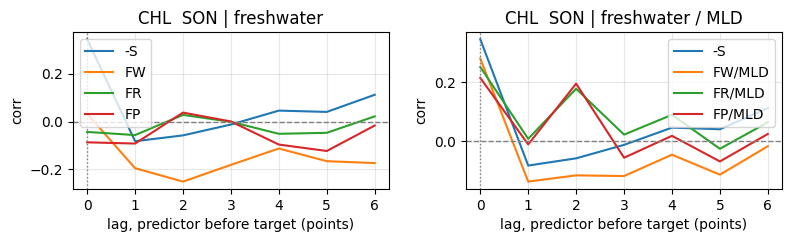

,season,target,predictor,cc_direct,R2_direct,p_direct,best_lag_past_predictor,cc_best,R2_best,p_best
0,ALL,CHL,-S,0.498069,0.248073,5.304321e-38,0,0.498069,0.248073,5.304321e-38
1,ALL,CHL,FW,0.116526,0.013578,4.772957e-03,0,0.116526,0.013578,4.772957e-03
2,ALL,CHL,FR,-0.014560,0.000212,7.252626e-01,5,0.113573,0.012899,6.178324e-03
3,ALL,CHL,FP,-0.095283,0.009079,2.117214e-02,0,-0.095283,0.009079,2.117214e-02
4,ALL,CHL,FW/MLD,0.418967,0.175533,2.869431e-26,0,0.418967,0.175533,2.869431e-26
5,ALL,CHL,FR/MLD,0.348025,0.121121,4.239738e-18,0,0.348025,0.121121,4.239738e-18
6,ALL,CHL,FP/MLD,0.207302,0.042974,4.230047e-07,2,0.215764,0.046554,1.435780e-07
7,DJF,CHL,-S,0.570258,0.325194,8.633454e-12,0,0.570258,0.325194,8.633454e-12
8,DJF,CHL,FW,0.003712,0.000014,9.677709e-01,2,0.161525,0.026090,7.926327e-02
9,DJF,CHL,FR,-0.083560,0.006982,3.621844e-01,6,0.209859,0.044041,2.438362e-02


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

d_in = feats.copy()
if "season" not in d_in.columns:
    d_in["season"] = d.loc[d_in.index, "season"].values

bgcstr = "CHL"
max_lag = 6
seasons = ["ALL", "DJF", "MAM", "JJA", "SON"]

def get_stats_local(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    f = np.isfinite(x) & np.isfinite(y)

    if f.sum() < 5:
        return np.nan, np.nan, np.nan

    cc, pval = stats.pearsonr(x[f], y[f])
    return cc, cc**2, pval

def lagged_corr_series_past_predictors(y, x, max_lag=6):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    lags = np.arange(0, max_lag + 1)
    corr = np.full(len(lags), np.nan)
    r2 = np.full(len(lags), np.nan)
    pval = np.full(len(lags), np.nan)

    for i, lag in enumerate(lags):
        if lag == 0:
            xx = x
            yy = y
        else:
            xx = x[:-lag]
            yy = y[lag:]

        corr[i], r2[i], pval[i] = get_stats_local(xx, yy)

    if np.all(~np.isfinite(corr)):
        return lags, corr, np.nan, np.nan, np.nan, np.nan

    imax = np.nanargmax(np.abs(corr))
    return lags, corr, lags[imax], corr[imax], r2[imax], pval[imax]

required = ["season", bgcstr, "S", "FW", "FR", "FP", "MLD"]
missing = [c for c in required if c not in d_in.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

fig_files = []
stats_rows = []

for season in seasons:

    d_work = d_in.copy() if season == "ALL" else d_in[d_in["season"] == season].copy()

    y0 = np.asarray(d_work[bgcstr], dtype=float)
    mld = np.asarray(d_work["MLD"], dtype=float)

    predictors = {
        "-S": -np.asarray(d_work["S"], dtype=float),
        "FW": np.asarray(d_work["FW"], dtype=float),
        "FR": np.asarray(d_work["FR"], dtype=float),
        "FP": np.asarray(d_work["FP"], dtype=float),
        "FW/MLD": np.asarray(d_work["FW"], dtype=float) / mld,
        "FR/MLD": np.asarray(d_work["FR"], dtype=float) / mld,
        "FP/MLD": np.asarray(d_work["FP"], dtype=float) / mld,
    }

    direct_names = ["-S", "FW", "FR", "FP"]
    mld_names = ["-S", "FW/MLD", "FR/MLD", "FP/MLD"]

    lag_results = {}

    for name, x in predictors.items():
        lags, corr, best_lag, best_cc, best_r2, best_pval = lagged_corr_series_past_predictors(
            y0, x, max_lag=max_lag
        )

        lag_results[name] = {
            "lags": lags,
            "corr": corr,
            "best_lag": best_lag,
            "best_cc": best_cc,
            "best_r2": best_r2,
            "best_pval": best_pval,
        }

        cc0, r20, p0 = get_stats_local(x, y0)

        stats_rows.append({
            "season": season,
            "target": bgcstr,
            "predictor": name,
            "cc_direct": cc0,
            "R2_direct": r20,
            "p_direct": p0,
            "best_lag_past_predictor": best_lag,
            "cc_best": best_cc,
            "R2_best": best_r2,
            "p_best": best_pval,
        })

    fig, axs = plt.subplots(1, 2, figsize=(8, 2.5))

    ax = axs[0]
    for name in direct_names:
        ax.plot(lag_results[name]["lags"], lag_results[name]["corr"], label=name)

    ax.axhline(0, linestyle="--", color="0.5", lw=1)
    ax.axvline(0, linestyle=":", color="0.5", lw=1)
    ax.legend()
    ax.set_xlabel("lag, predictor before target (points)")
    ax.set_ylabel("corr")
    ax.set_title(bgcstr + "  " + season + " | freshwater")
    ax.grid(alpha=0.3)

    ax = axs[1]
    for name in mld_names:
        ax.plot(lag_results[name]["lags"], lag_results[name]["corr"], label=name)

    ax.axhline(0, linestyle="--", color="0.5", lw=1)
    ax.axvline(0, linestyle=":", color="0.5", lw=1)
    ax.legend()
    ax.set_xlabel("lag, predictor before target (points)")
    ax.set_ylabel("corr")
    ax.set_title(bgcstr + "  " + season + " | freshwater / MLD")
    ax.grid(alpha=0.3)

    fig.tight_layout(pad=1)

    fig_filename = f"LAG_PASTPRED_CORR_{bgcstr}_{season}_maxlag{max_lag}.png"
    fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
    plt.show()

    fig_files.append(fig_filename)

df_lag_stats = pd.DataFrame(stats_rows)
display(df_lag_stats)

csv_name = f"LAG_PASTPRED_CORR_{bgcstr}_stats.csv"
xlsx_name = f"LAG_PASTPRED_CORR_{bgcstr}_stats.xlsx"

df_lag_stats.to_csv(csv_name, index=False)
df_lag_stats.to_excel(xlsx_name, index=False)

for f in fig_files:
    files.download(f)

files.download(csv_name)
files.download(xlsx_name)

### Figures CLIMATO

In [ ]:
feats.columns

Index(['wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime', 'CHL', 'log10(CHL)',
       'MLD', 'LE', 'LEclim', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV',
       'CRI', 'FW', 'FR', 'FP', 'u', 'v', 'WD', '|U|', 'u3', 'v3', 'wdir3',
       'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3', 'u1', 'v1', 'wdir1', 'uuvv1',
       'P-E', 'Precip', 'CumPrecip', 'P', 'CPREC_cmcc', 'ppppp_cmcc', 'S+',
       'Sbottom', 'S', 'T', 'N1meanA', 'N1bulk', 'DOXY', 'AMON', 'NTRA',
       'NTRI', 'DINO', 'PHOS', 'SLCA', 'DINO+0.5CHL', 'NTRI+0.5CHL',
       'NTRA+0.5CHL', 'log10(DOXY)', 'log10(AMON)', 'log10(NTRA)',
       'log10(NTRI)', 'log10(DINO)', 'log10(PHOS)', 'log10(SLCA)',
       'log10(DINO+0.5CHL)', 'log10(NTRI+0.5CHL)', 'log10(NTRA+0.5CHL)',
       'index'],
      dtype='object')

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from google.colab import files

def plot_monthly_box_season_pdfs(
    df,
    var="CRI",
    month_col="mm",
    color="k",
    title=r"$V$ $(m^{3})$",
    ylabel=None,
    fig_filename="CLIMATO_CRI",
    ymin=None,
    ymax=None,
    pdf_width=3,
    bw=0.3,
    dpi=600,
    download=True
):
    dplot = df.copy()

    x = np.asarray(dplot[month_col], dtype=float)
    y = np.asarray(dplot[var], dtype=float)

    bx = np.arange(1, 13)
    allx = 14

    season_defs = {
        "Yearly": np.isfinite(x),
        "Winter\nDJF": (x == 12) | (x <= 2),
        "Spring\nMAM": (x >= 3) & (x <= 5),
        "Summer\nJJA": (x >= 6) & (x <= 8),
        "Autumn\nSON": (x >= 9) & (x <= 11),
    }

    season_pos = {
        "Yearly": allx,
        "Winter\nDJF": allx + 3,
        "Spring\nMAM": allx + 6,
        "Summer\nJJA": allx + 9,
        "Autumn\nSON": allx + 12,
    }

    fig, ax = plt.subplots(1, 1, figsize=(7, 2.5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    means_x = []
    means_y = []

    wdth = 0.45

    for m in bx:
        yy = y[x == m]
        yy = yy[np.isfinite(yy)]

        if len(yy) > 1:
            ax.boxplot(
                yy,
                positions=[m],
                tick_labels=[""],
                vert=True,
                showfliers=False,
                widths=wdth,
                boxprops=dict(color=color),
                whiskerprops=dict(color=color),
                capprops=dict(color=color),
                medianprops=dict(color=color),
            )

            means_x.append(m)
            means_y.append(np.nanmean(yy))

    ax.plot(means_x, means_y, ".", color=color, markersize=5)
    ax.plot(means_x, means_y, "-", color=color, lw=0.7)

    for sname, mask in season_defs.items():

        yy = y[mask]
        yy = yy[np.isfinite(yy)]

        if len(yy) < 2:
            continue

        pos = season_pos[sname]

        ax.boxplot(
            yy,
            positions=[pos],
            tick_labels=[""],
            vert=True,
            showfliers=False,
            widths=wdth,
            boxprops=dict(color=color),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
            medianprops=dict(color=color),
        )

        ax.plot(pos, np.nanmean(yy), ".", color=color, markersize=5)

        if len(yy) > 3 and np.nanstd(yy) > 0:
            ymin_pdf = np.nanmin(yy) if ymin is None else ymin
            ymax_pdf = np.nanmax(yy) if ymax is None else ymax
            yy_grid = np.linspace(ymin_pdf, ymax_pdf, 300)

            kde = gaussian_kde(yy, bw_method=bw)
            dens = kde(yy_grid)

            if np.nanmax(dens) > 0:
                dens = pdf_width * dens / np.nanmax(dens)

                ax.plot(pos + dens, yy_grid, "-", color=color, lw=1)
                ax.fill_betweenx(
                    yy_grid,
                    pos,
                    pos + dens,
                    color=color,
                    alpha=0.2,
                )

    xticks = list(bx) + list(season_pos.values())
    xticklabels = [
        "J", "F", "M", "A", "M", "J",
        "J", "A", "S", "O", "N", "D"
    ] + list(season_pos.keys())

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    ax.set_xlim(0.5, max(season_pos.values()) + pdf_width + 1)

    if ymin is not None or ymax is not None:
        ax.set_ylim(ymin, ymax)

    #ax.set_title(title, loc="left")
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.grid(alpha=0.25)

    fig.tight_layout(pad=1)

    png_name = fig_filename + ".png"
    pdf_name = fig_filename + ".pdf"

    fig.savefig(png_name, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_name, bbox_inches="tight")

    plt.show()

    if download:
        files.download(png_name)
        files.download(pdf_name)

    return fig, ax

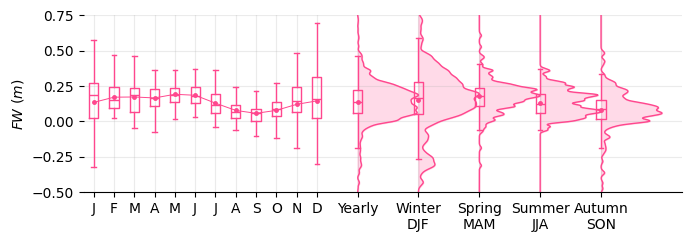

In [21]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="FW",
    month_col="mm",
    color="#ff478e",
    title=None,
    ylabel=r"$FW$ $(m)$",
    fig_filename="CLIMATO_FW",
    ymin=-0.5,
    ymax=0.75,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=False
)

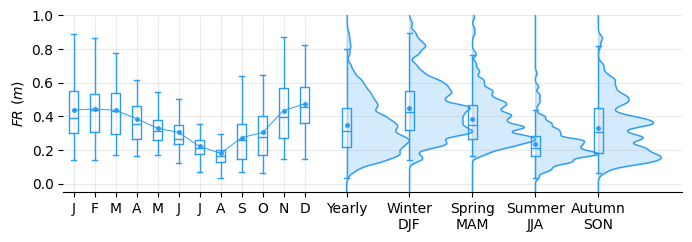

In [22]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="FR",
    month_col="mm",
    color="#2a9bf7",
    title=None,
    ylabel=r"$FR$ $(m)$",
    fig_filename="CLIMATO_FR",
    ymin=-.05,
    ymax=1,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=False
)

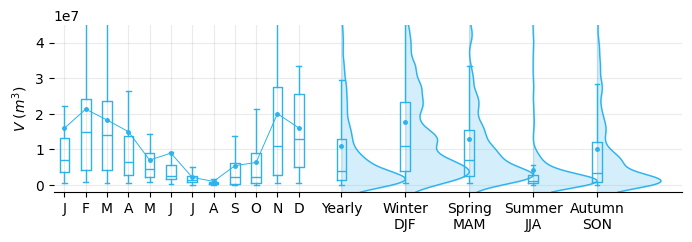

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="CRI",
    month_col="mm",
    color="#2bb3ed",
    title=None,
    ylabel=r"$V$ $(m^{3})$",
    fig_filename="CLIMATO_CRI",
    ymin=-0.2e7,
    ymax=4.5e7,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=True
)




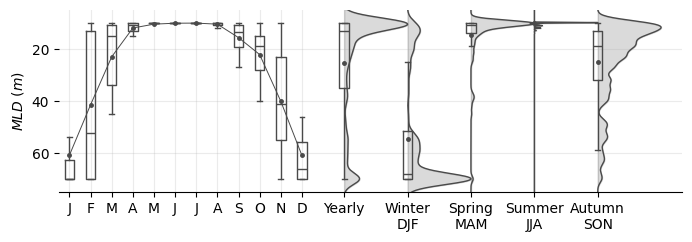

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="MLD",
    month_col="mm",
    color="#4a4a4a",
    title=None,
    ylabel=r"$MLD$ $(m)$",
    fig_filename="CLIMATO_MLD",
    ymin=75,
    ymax=5,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=True
)

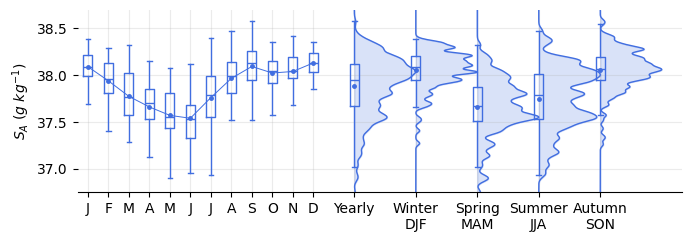

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="Ssurface",
    month_col="mm",
    color="#416ee0",
    title=None,
    ylabel=r"$S_A$ $(g \ kg^{-1})$",
    fig_filename="CLIMATO_SAL",
    ymin=36.75,
    ymax=38.7,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=True
)



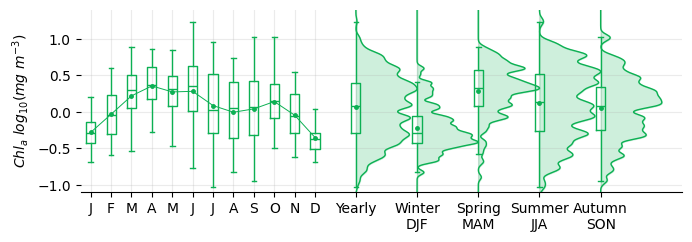

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="chl10",
    month_col="mm",
    color="#0cb053",
    title=None,
    ylabel=r"$Chl_a$ $log_{10}(mg \ m^{-3})$",
    fig_filename="CLIMATO_LOG10CHL",
    ymin=-1.1,
    ymax=1.4,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=True
)




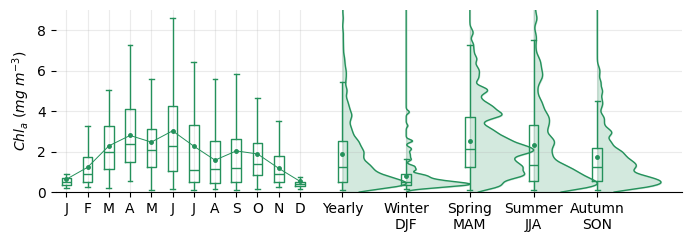

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
fig, ax = plot_monthly_box_season_pdfs(
    df=d,
    var="chl",
    month_col="mm",
    color="#24915b",
    title=None,
    ylabel=r"$Chl_a$ $(mg \ m^{-3})$",
    fig_filename="CLIMATO_CHL",
    ymin=0,
    ymax=9,
    pdf_width=3,
    bw=0.1,
    dpi=600,
    download=True
)

### Figures MODELS H, S

In [ ]:
Smodel0 = SmaxSummer *(1-FW_to_MLD) Smodel00 = SmaxConst *(1-FW_to_MLD)

Smodel1 = SmaxSummer *(1-FR_to_MLD) Smodel11 = SmaxConst *(1-FR_to_MLD)

Smodel2 = SmaxSummer *(1-FR_to_LEC) Smodel22 = SmaxConst *(1-FR_to_LEC) Smodel3 = SmaxSummer *(1-FR_to_LEC_STAR) Smodel33 = SmaxConst *(1-FR_to_LEC_STAR)

Smodel4 = SmaxSummer *(1-FR_to_LE) Smodel44 = SmaxConst *(1-FR_to_LE) Smodel5 = SmaxSummer *(1-FR_to_LE_STAR) Smodel55 = SmaxConst *(1-FR_to_LE_STAR)

Smodel6 = SmaxSummer *(1-FR_to_LC) Smodel66 = SmaxConst *(1-FR_to_LC) Smodel7 = SmaxSummer *(1-FR_to_LC_STAR) Smodel77 = SmaxConst *(1-FR_to_LC_STAR)

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from datetime import datetime
from IPython.display import display
from google.colab import files

def plot_models_timeseries_interannual(
    df,
    obs_col,
    model_cols,
    model_labels,
    fig_filename,
    y_label="",
    obs_label="Obs.",
    obs_color="0.5",
    model_color="k",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=None,
    bw=None,
    dpi=600,
    download=True
):
    dt = np.array(df[date_col]).astype("datetime64")
    years = np.array(df[year_col])
    A = np.asarray(df[obs_col], dtype=float)

    if len(model_cols) == 1:
        model_alphas = [1.0]
    else:
        model_alphas = np.linspace(1.0, 0.45, len(model_cols))

    stats_rows = []

    for col, lab in zip(model_cols, model_labels):
        P = np.asarray(df[col], dtype=float)

        MAE, MEDAE, MAXE, MSE, RMSE, MAPE, RSQU, EXVA, PEAR, PEAV, R2, PV, CF, SL, SE = get_metrucs(
            A, P, True, 3, False
        )

        stats_rows.append({
            "obs": obs_col,
            "model": col,
            #"label": lab,
            "Pearson": PEAR,
            "p-value": PEAV,
            "R2": RSQU,
            "ExplainedVar": EXVA,
            "MAE": MAE,
            "MEDAE": MEDAE,
            "MSE": MSE,
            "RMSE": RMSE,
            "MAPE": MAPE
        })

    df_stats = pd.DataFrame(stats_rows)
    display(df_stats)

    obs_ia = beaning_mean(A, ia_years, years)

    mod_ia = {
        col: beaning_mean(np.asarray(df[col], dtype=float), ia_years, years)
        for col in model_cols
    }

###

    dt_ia = np.array([datetime(y, 6, 1) for y in ia_years])

    if bw is None:
        fig = plt.figure(figsize=(11, 3))
        gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2])
        ax_ts = fig.add_subplot(gs[0])
        ax_ia = fig.add_subplot(gs[1])
    else:
        fig = plt.figure(figsize=(17, 4))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1.4, 4, 2])
        ax_pdf = fig.add_subplot(gs[0])
        ax_ts = fig.add_subplot(gs[1])
        ax_ia = fig.add_subplot(gs[2])

    if bw is not None:
        yy_obs = A[np.isfinite(A)]
        all_vals = [yy_obs]

        for col in model_cols:
            yy = np.asarray(df[col], dtype=float)
            all_vals.append(yy[np.isfinite(yy)])

        xmin = np.nanmin([np.nanmin(v) for v in all_vals if len(v) > 0])
        xmax = np.nanmax([np.nanmax(v) for v in all_vals if len(v) > 0])
        xx = np.linspace(xmin, xmax, 300)

        if len(yy_obs) > 2 and np.nanstd(yy_obs) > 0:
            kde = gaussian_kde(yy_obs, bw_method=bw)
            ax_pdf.plot(kde(xx), xx, color=obs_color, lw=1, alpha=1, label=obs_label)

        for col, lab, alp in zip(model_cols, model_labels, model_alphas):
            yy = np.asarray(df[col], dtype=float)
            yy = yy[np.isfinite(yy)]

            if len(yy) > 2 and np.nanstd(yy) > 0:
                kde = gaussian_kde(yy, bw_method=bw)
                ax_pdf.plot(kde(xx), xx, color=model_color, lw=1, alpha=alp, label=lab)

        ax_pdf.set_xlabel("Density")
        ax_pdf.set_ylabel(y_label)
        ax_pdf.grid(alpha=0.3)

        if invert_y:
            ax_pdf.invert_yaxis()

    ax_ts.plot(dt, A, "-", color=obs_color, alpha=1, label=obs_label, lw=1)

    for col, lab, alp in zip(model_cols, model_labels, model_alphas):
        ax_ts.plot(
            dt,
            np.asarray(df[col], dtype=float),
            "-",
            color=model_color,
            alpha=alp,
            label=lab,
            lw=1
        )

    ax_ts.legend(loc=4, fontsize=8)
    ax_ts.set_xlim(*weekly_xlim)
    #ax_ts.set_ylabel(y_label, fontsize=12)
    ax_ts.set_title(y_label, fontsize=12,loc='left')
    ax_ts.grid(alpha=0.3)

    if invert_y:
        ax_ts.invert_yaxis()

    ax_ia.plot(
        dt_ia,
        obs_ia,
        "-",
        color=obs_color,
        alpha=1,
        lw=1,
        label=obs_label + " annual"
    )

    for col, lab, alp in zip(model_cols, model_labels, model_alphas):
        ax_ia.plot(
            dt_ia,
            mod_ia[col],
            "-",
            color=model_color,
            alpha=alp,
            lw=1,
            label=lab + " annual"
        )
    if obs_col == 'S':
      ax_ia.legend(loc=3, fontsize=8)
    else: ax_ia.legend(loc=4, fontsize=8)
    ax_ia.set_xlim(*ia_xlim)
    ax_ia.set_title(y_label, fontsize=12,loc='left')
    ax_ia.grid(alpha=0.3)

    if ia_ylim is not None:
        ax_ia.set_ylim(*ia_ylim)

    if invert_y:
        ax_ia.invert_yaxis()

    fig.tight_layout(pad=1)

    png_name = fig_filename + ".png"
    pdf_name = fig_filename + ".pdf"
    csv_name = fig_filename + "_stats.csv"
    xlsx_name = fig_filename + "_stats.xlsx"

    fig.savefig(png_name, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_name, bbox_inches="tight")

    df_stats.to_csv(csv_name, index=False)
    df_stats.to_excel(xlsx_name, index=False)

    plt.show()

    if download:
        files.download(png_name)
        files.download(pdf_name)
        files.download(csv_name)
        files.download(xlsx_name)

    return df_stats, fig

,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,MLD,LE,0.750,0.0,0.542,0.542,10.695,7.145,208.364,14.435,0.544
1,MLD,LEclim,0.655,0.0,0.428,0.429,11.556,7.136,259.827,16.119,0.573


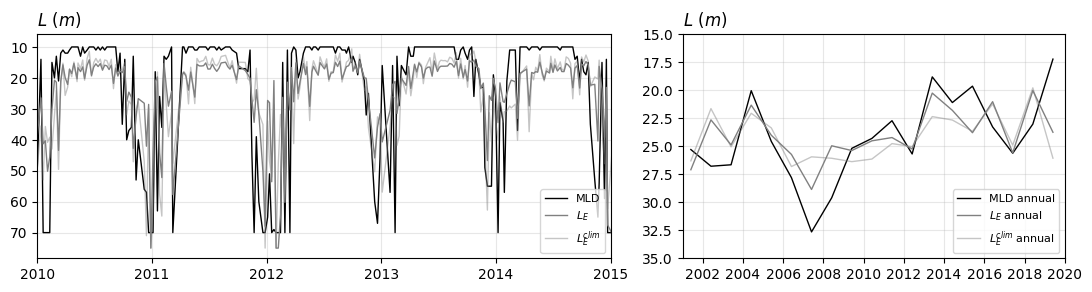

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
np.NaN = np.nan
df_stats, fig = plot_models_timeseries_interannual(
    df=feats,
    obs_col="MLD",
    model_cols=["LE", "LEclim"],
    model_labels=[r"$L_E$", r"$L_E^{clim}$"],
    fig_filename="FIGURE_MODELS_MLD",
    y_label=r"$L$ $(m)$",
    obs_label="MLD",
    obs_color = 'k', #obs_color=clr_mld,
    model_color = 'gray' , #model_color="#e34491",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=True,
    ia_ylim=(15, 35),
    bw=None,
    dpi=600,
    download=True
)

In [45]:
d_sali_models = feats.copy()

x = d_sali_models['S']
y =  np.array(d['SmaxSummer']) * (1 - np.array(d['FR']) / np.array(d['LE']))

coef = np.polyfit(y, x, 1)
P_adj = coef[0]*y + coef[1]

coef

array([ 0.45858776, 20.60833007])

In [46]:
d_sali_models = feats.copy()
x = d_sali_models['S']

y =  np.array(d['SmaxSummer']) * (1 - np.array(d['FR']) / np.array(d['MLD']))
d_sali_models['Smodel0'] = y

y =  np.array(d['SmaxSummer']) * (1 - np.array(d['FR']) / np.array(d['LE']))
d_sali_models['Smodel1'] = y

y =  38.65 * (1 - np.array(d['FR']) / np.array(d['LE_STAR']))
d_sali_models['Smodel2'] = y



,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,S,Smodel0,0.646,0.0,-2.72,-0.967,0.467,0.358,0.412,0.642,0.012


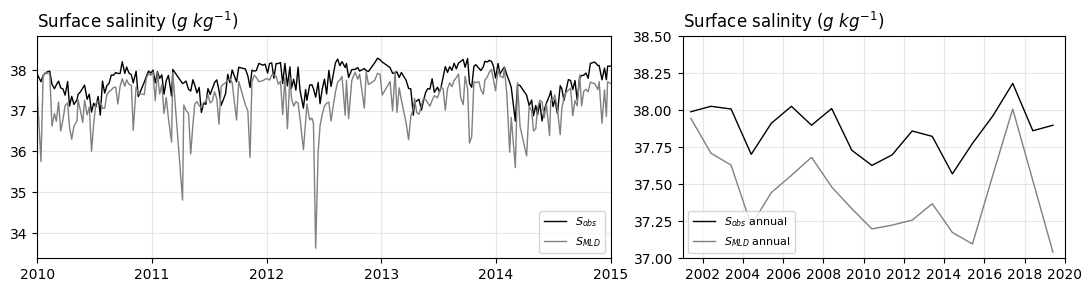

In [53]:
np.NaN = np.nan
df_stats, fig = plot_models_timeseries_interannual(
    df=d_sali_models,
    obs_col="S",
    model_cols=["Smodel0"],
    model_labels=[r"$S_{MLD}$"],
    fig_filename="FIGURE_MODELS_SAL",
    y_label=r"Surface salinity $(g \ kg^{-1})$",
    obs_label="$S_{obs}$",
    obs_color = 'k', # obs_color=clr_mld,
    model_color= 'gray' , #model_color="b",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(37,38.5),
    bw=None,
    dpi=600,
    download=False
)

,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,S,Smodel1,0.483,0.0,-0.551,-0.092,0.330,0.281,0.172,0.415,0.009
1,S,Smodel2,0.401,0.0,-0.409,-0.187,0.314,0.267,0.156,0.395,0.008


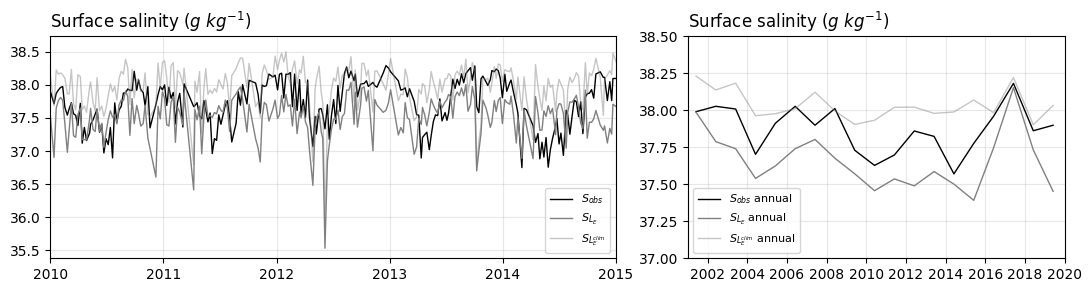

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
df_stats, fig = plot_models_timeseries_interannual(
    df=d_sali_models,
    obs_col="S",
    model_cols=["Smodel1", "Smodel2"],
    model_labels=[r"$S_{L_E}$", r"$S_{L_E^{clim}}$"],
    fig_filename="FIGURE_MODELS_SAL",
    y_label=r"Surface salinity $(g \ kg^{-1})$",
    obs_label="$S_{obs}$",
    obs_color = 'k', # obs_color=clr_mld,
    model_color= 'gray' , #model_color="b",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(37,38.5),
    bw=None,
    dpi=600,
    download=True
)

,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,FW,FR,0.322,0.0,-0.039,0.030,0.106,0.073,0.022,0.150,7.713
1,FW,FP,0.153,0.0,-0.486,-0.388,0.136,0.106,0.032,0.179,10.234


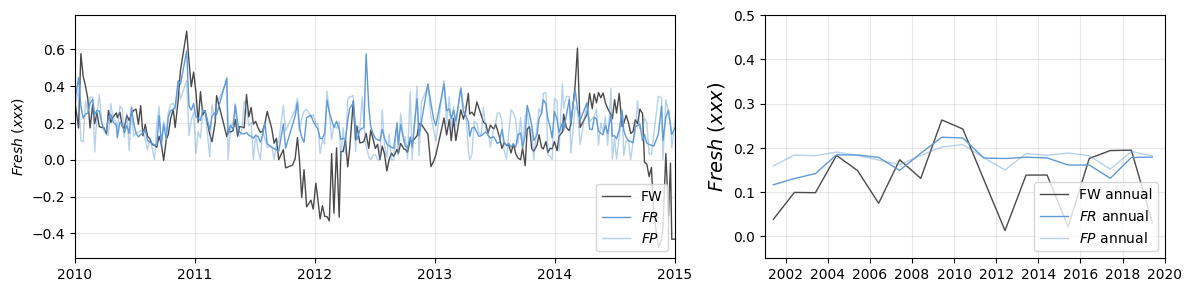

In [214]:
feaaa = feats.copy()

feaaa["FW"] = (feats["FW"])
feaaa["FR"] = (feats["FR"])/2
feaaa["FP"] = (feats["FP"]) /2

df_stats, fig = plot_models_timeseries_interannual(
    df=feaaa,
    obs_col="FW",
    model_cols=["FR", "FP"],
    model_labels=[r"$FR$", r"$FP$"],
    fig_filename="FIGURE_MODELS_SAL",
    y_label=r"$Fresh$ $(xxx)$",
    obs_label="FW",
    obs_color=clr_mld,
    model_color="#5f9ad9",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(-0.05,0.50),
    bw=None,
    dpi=600,
    download=False
)

,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,FW,FR,0.435,0.0,-0.282,-0.097,0.133,0.105,0.031,0.176,4.394
1,FW,FP,0.223,0.0,-2.461,-1.683,0.233,0.200,0.083,0.288,6.934


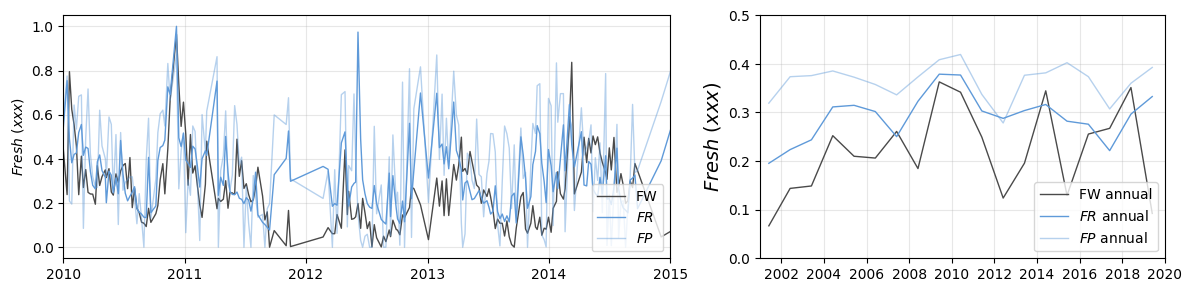

In [215]:
feaaa = feats.copy()

mask = feaaa["FW"] > 0
feaaa_pos = feaaa[mask].copy()

feaaa_pos["FW"] = normalize_pm1(feaaa_pos["FW"])
feaaa_pos["FR"] = normalize_pm1(feaaa_pos["FR"])
feaaa_pos["FP"] = normalize_pm1(feaaa_pos["FP"])



df_stats, fig = plot_models_timeseries_interannual(
    df=feaaa_pos,
    obs_col="FW",
    model_cols=["FR", "FP"],
    model_labels=[r"$FR$", r"$FP$"],
    fig_filename="FIGURE_MODELS_SAL",
    y_label=r"$Fresh$ $(xxx)$",
    obs_label="FW",
    obs_color=clr_mld,
    model_color="#5f9ad9",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2010, 1, 1), datetime(2015, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(0,0.50),
    bw=None,
    dpi=600,
    download=False
)



### Supp figure FR FP (FW)

In [61]:
def normalize_pm1(x):
    import numpy as np

    x = np.asarray(x, dtype=float)

    f = np.isfinite(x)
    if f.sum() == 0:
        return x * np.nan

    xmax = np.nanmax(np.abs(x))

    if not np.isfinite(xmax) or xmax == 0:
        return np.full_like(x, np.nan)

    return x / xmax

In [63]:
def normalize_pm1_minmax(x):
    import numpy as np

    x = np.asarray(x, dtype=float)

    f = np.isfinite(x)
    if f.sum() == 0:
        return x * np.nan

    xmin = np.nanmin(x)
    xmax = np.nanmax(x)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax == xmin:
        return np.full_like(x, np.nan)

    return 2 * (x - xmin) / (xmax - xmin) - 1

In [64]:
feaaa = feats.copy()
feaaa["datetime"] = feats["datetime"].values
feaaa["yyyy"] = feats["yyyy"].values

feaaa["FW"] = normalize_pm1(feats["FW"])
feaaa["FR"] = normalize_pm1(feats["FR"])
feaaa["FP"] = normalize_pm1(feats["FP"])


def lowpass_exp(x, N=5):
    import pandas as pd
    x = pd.Series(x)
    return x.ewm(span=N, adjust=False).mean().values
feaaa["FP_lp"] = lowpass_exp(feaaa["FP"], N=3)

x = np.array(feaaa["FR"])
y = np.array(feaaa["FP"])

print(np.nansum(x))
print(np.nansum(y))
fac1 = np.nansum(y)/np.nansum(x)
print(fac1,1-1/fac1)

feaaa["FPr"] = normalize_pm1(feats["FP"])/fac1

yr = np.array(feaaa["FPr"])
print(np.nansum(x))
print(np.nansum(yr))
facr = np.nansum(yr)/np.nansum(x)
print(facr,1-1/facr)

245.10072802363968
305.5095493811483
1.2464652873315099 0.19773136872439834
245.10072802363968
245.1007280236397
1.0000000000000002 2.220446049250313e-16


,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,FP,FR,0.673,0.0,0.357,0.45,0.155,0.134,0.036,0.189,NaN


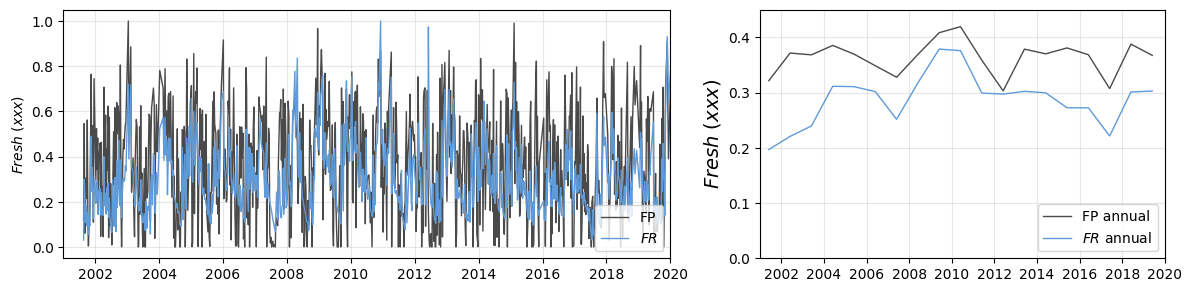

,obs,model,Pearson,p-value,R2,ExplainedVar,MAE,MEDAE,MSE,RMSE,MAPE
0,FPr,FR,0.673,0.0,0.441,0.441,0.111,0.093,0.02,0.142,NaN


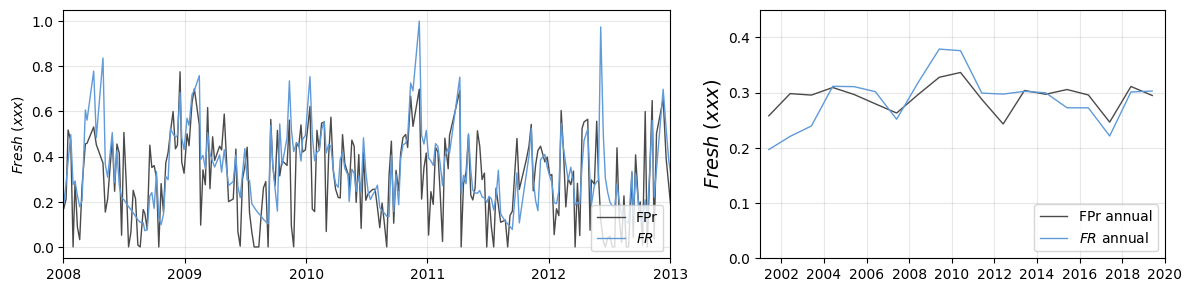

In [65]:
df_stats, fig = plot_models_timeseries_interannual(
    df=feaaa,
    obs_col="FP",
    obs_label=r"FP",
    model_cols=['FR',],
    model_labels=[r"$FR$"],
    fig_filename="FIGURE_MODELS_FRFP",
    y_label=r"$Fresh$ $(xxx)$",
    obs_color=clr_mld,
    model_color="#5f9ad9",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(0,0.45),
    bw=None,
    dpi=600,
    download=False
)


df_stats, fig = plot_models_timeseries_interannual(
    df=feaaa,
    obs_col="FPr",
    obs_label=r"FPr",
    model_cols=['FR',],
    model_labels=[r"$FR$"],
    fig_filename="FIGURE_MODELS_FRFPr",
    y_label=r"$Fresh$ $(xxx)$",
    obs_color=clr_mld,
    model_color="#5f9ad9",
    date_col="datetime",
    year_col="yyyy",
    weekly_xlim=(datetime(2008, 1, 1), datetime(2013, 1, 1)),
    ia_years=np.arange(2001, 2020),
    ia_xlim=(datetime(2001, 1, 1), datetime(2020, 1, 1)),
    invert_y=False,
    ia_ylim=(0,0.45),
    bw=None,
    dpi=600,
    download=False
)

In [66]:
feaaa = feats.copy()
feaaa["datetime"] = feats["datetime"].values
feaaa["yyyy"] = feats["yyyy"].values

feaaa["FW"] = normalize_pm1(feats["FW"])
feaaa["FR"] = normalize_pm1(feats["FR"])
feaaa["FP"] = normalize_pm1(feats["FP"])


feaaa["FW"] = normalize_01_safe(feats["FW"])
feaaa["FR"] = normalize_01_safe(feats["FR"])
feaaa["FP"] = normalize_01_safe(feats["FP"])


x = np.array(feaaa["FR"])
y = np.array(feaaa["FP"])

print(np.nansum(x))
print(np.nansum(y))
fac1 = np.nansum(y)/np.nansum(x)
print(fac1,1-1/fac1)

226.33754061569883
305.5095493811483
1.3497961873672408 0.25914741102470706


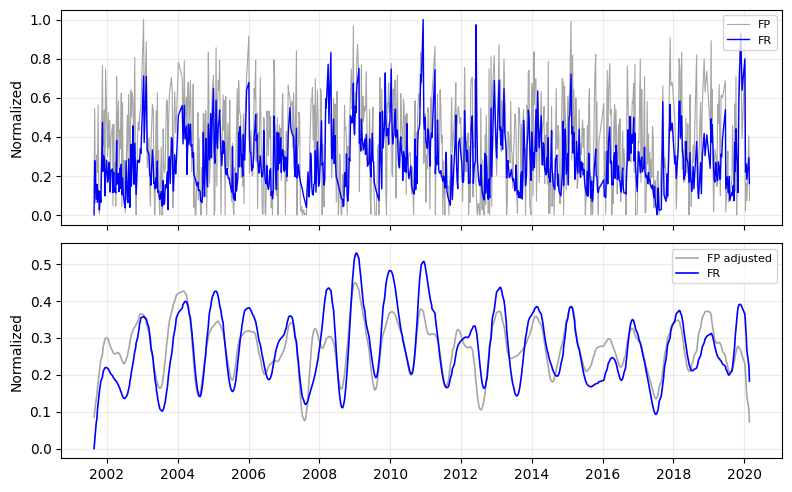

FP/FR normalization ratio = 1.35


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

dfp = feats.copy()

dt = np.array(dfp["datetime"]).astype("datetime64")
FR = normalize_01_safe(dfp["FR"])
FP = normalize_01_safe(dfp["FP"])

ratio_FP_FR = np.nansum(FP) / np.nansum(FR)
FP_adj = FP / ratio_FP_FR

Nlo = 52
res = 1
fny = 1 / (2 * res)
locu = 1 / Nlo

FR_lo = filtre_butter(FR, cutoff=locu, fs=fny, ordre=2)
FP_lo = filtre_butter(FP, cutoff=locu, fs=fny, ordre=2)
FP_adj_lo = filtre_butter(FP_adj, cutoff=locu, fs=fny, ordre=2)

fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axs[0].plot(dt, FP, color="0.65", lw=0.8, label="FP")
axs[0].plot(dt, FR, color="blue", lw=1.0, label="FR")
axs[0].set_ylabel("Normalized")
axs[0].legend(fontsize=8, loc=1)
axs[0].grid(alpha=0.25)

axs[1].plot(dt, FP_adj_lo, color="0.65", lw=1.2, label="FP adjusted")
axs[1].plot(dt, FR_lo, color="blue", lw=1.2, label="FR")
axs[1].set_ylabel("Normalized")
axs[1].legend(fontsize=8, loc=1)
axs[1].grid(alpha=0.25)

fig.tight_layout(pad=1)

fig_filename = "FIGURE_S1_FR_FP_adjusted.png"
fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
plt.show()

print("FP/FR normalization ratio =", np.round(ratio_FP_FR, 3))

files.download(fig_filename)

In [217]:
ratio_FP_FR

np.float64(1.3497961873672408)

### NORMALIZATIONS [0-1]

In [23]:
def normalize_01_safe(s):
    s = pd.to_numeric(s, errors="coerce")
    vmin, vmax = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
        return s * np.nan
    return (s - vmin) / (vmax - vmin)

In [24]:
feats_norm = feats.copy()

num_cols = feats.select_dtypes(include=[np.number]).columns

for col in num_cols:
    feats_norm[col] = normalize_01_safe(feats[col])
print("normalized numeric columns:", len(num_cols))
print("feats:", feats.shape)
print("feats_norm:", feats_norm.shape)


# --- aligned dropna, safer than dropping separately ---
valid_index = feats.dropna().index.intersection(feats_norm.dropna().index)

feats = feats.loc[valid_index].copy()
feats_norm = feats_norm.loc[valid_index].copy()

print("after aligned dropna")
print("feats:", feats.shape)
print("feats_norm:", feats_norm.shape)


normalized numeric columns: 45
feats: (839, 47)
feats_norm: (839, 47)
after aligned dropna
feats: (839, 47)
feats_norm: (839, 47)


### RUN DOOMFOREST

In [25]:
for var in list(globals()):
    if var.startswith("rf_for_"):
        del globals()[var]

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [15]:
# in case WITH_BGC == True : Initial RF with all bgc feats (but less points)
experience = 'CORE'
RUN_LIST = []
RUN_LIST.append([['log10(CHL)'],['T','S',
                  'DOXY', 'AMON', 'NTRA', 'NTRI', 'DINO', 'PHOS', 'SLCA',
                  'P','FW','MLD','|U|','WD'],2,1/3,'','C00'])

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

RUN_OUT = []
RF_MODELS = {}

n_estimators = 100
rs = np.array([1092, 7288, 6723, 5953, 519, 435, 4297, 1965, 8758, 4943, 4461,
               9932, 2248, 6082, 1712, 9054, 8759, 8150, 4500, 4198, 5987, 9296,
               8902, 207, 8910, 2158, 972, 8582, 2861, 1320, 2482, 8837, 2429,
               4036, 4378, 2837, 1583, 5329, 3458, 1047, 9263, 8682, 9834, 3798,
               5546, 4633, 36, 5940, 9215, 498, 200, 972, 8591, 6979, 4483,
               4985, 9662, 8110, 7154, 7825, 2634, 753, 8591, 7844, 9757, 3242,
               9270, 746, 2161, 2976, 9575, 8217, 3256, 2539, 4135, 5915, 3916,
               4476, 6962, 4687, 5540, 6551, 9033, 3002, 2518, 3013, 5443, 2856,
               9495, 7665, 3800, 6267, 3700, 3466, 5822, 564, 28, 5077, 9099,
               5257])
TN = np.arange(len(rs))

for r in range(len(RUN_LIST)):

    learning_variable = RUN_LIST[r][0]
    training_sub_list = RUN_LIST[r][1]
    TAKENORM = RUN_LIST[r][2]
    test_size = RUN_LIST[r][3]
    note = RUN_LIST[r][4]
    trnm = RUN_LIST[r][5]

    label_stri = learning_variable[0]

    if len(note) == 0:
        note = "rf_for_X"

    str_rf = note

    if label_stri == "CHL":
        clr_var = clr_chl
        label_var = "$Chl_{a}$ $(mg \\ m^{-3})$"
    elif label_stri == "log10(CHL)":
        clr_var = clr_chl
        label_var = "$Chl_{a}$ $log_{10}(mg \\ m^{-3})$"
    elif label_stri == "S":
        clr_var = clr_sal
        label_var = "$S_{A}$ $(g \\ kg^{-1})$"
    else:
        clr_var = "#ff5996"
        label_var = label_stri

    if TAKENORM == 1:
        feats_INPUT = feats_norm.copy()
        label_INPUT = feats_norm[[label_stri]].copy()
    elif TAKENORM == 2:
        feats_INPUT = feats_norm.copy()
        label_INPUT = feats[[label_stri]].copy()
    else:
        feats_INPUT = feats.copy()
        label_INPUT = feats[[label_stri]].copy()

    missing = [c for c in training_sub_list + ["index"] if c not in feats_INPUT.columns]
    if missing:
        raise KeyError(f"Missing columns for {trnm}: {missing}")

    feats_sub_all = feats_INPUT[training_sub_list]
    index_all = np.array(feats_INPUT["index"])
    label_all = np.array(label_INPUT[label_stri])

    SCORE = []
    IMPOR = []

    METRIC_PEAR = []
    METRIC_PEAV = []
    METRIC_RSQU = []
    METRIC_EXVA = []
    METRIC_MAE = []
    METRIC_MEDAE = []
    METRIC_MSE = []
    METRIC_RMSE = []
    METRIC_MAPE = []

    RF_MODELS[str_rf] = []

    for tn, random_state in enumerate(rs):

        feats_train, feats_valid, label_train, label_valid = train_test_split(
            feats_INPUT,
            label_INPUT,
            test_size=test_size,
            random_state=int(random_state)
        )

        index_valid = np.array(feats_valid["index"])

        feats_sub_train = feats_train[training_sub_list]
        feats_sub_valid = feats_valid[training_sub_list]

        Nall = feats_sub_all.shape[0]
        Ntra = feats_sub_train.shape[0]
        Nval = feats_sub_valid.shape[0]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=int(random_state),
            oob_score=True
        )

        rf.fit(feats_sub_train, np.ravel(label_train.values))

        RF_MODELS[str_rf].append(rf)

        SCORE.append(rf.score(feats_sub_valid, label_valid) * 100)
        IMPOR.append(100 * np.round(rf.feature_importances_, 5))

        pred = rf.predict(feats_sub_valid)

        isort = np.argsort(index_valid)
        y_valid = np.array(label_valid)[isort].flatten()
        y_pred = np.array(pred)[isort].flatten()

        MAE, MEDAE, MAXE, MSE, RMSE, MAPE, RSQU, EXVA, PEAR, PEAV, R2, PV, CF, SL, SE = get_metrucs(
            y_valid, y_pred, True, 3, False
        )

        METRIC_PEAR.append(PEAR)
        METRIC_PEAV.append(PEAV)
        METRIC_RSQU.append(RSQU)
        METRIC_EXVA.append(EXVA)
        METRIC_MAE.append(MAE)
        METRIC_MEDAE.append(MEDAE)
        METRIC_MSE.append(MSE)
        METRIC_RMSE.append(RMSE)
        METRIC_MAPE.append(MAPE)

    IMPOR = np.array(IMPOR)

    m0 = np.nanmean(SCORE)
    m1 = np.nanmean(METRIC_PEAR)
    m2 = np.nanmean(METRIC_PEAV)
    m3 = np.nanmean(METRIC_RSQU)
    m4 = np.nanmean(METRIC_EXVA)
    m5 = np.nanmean(METRIC_MAE)
    m6 = np.nanmean(METRIC_MEDAE)
    m7 = np.nanmean(METRIC_MSE)
    m8 = np.nanmean(METRIC_RMSE)
    m9 = np.nanmean(METRIC_MAPE)

    PROJ = np.empty((len(RF_MODELS[str_rf]), feats_sub_all.shape[0])) * np.nan

    for tn, rf in enumerate(RF_MODELS[str_rf]):
        PROJ[tn, :] = rf.predict(feats_sub_all)

    proj = np.nanmean(PROJ, axis=0)

    if label_stri == "S":
        if trnm == "S*":
            col = "S*"
        elif trnm == "S**":
            col = "S**"
        else:
            col = "S_from_RF"

        feats[col] = proj
        feats_norm[col] = normalize_01_safe(feats[col]) # normalize_01

        feats["dS"] = np.array(feats["S"]) - proj
        feats_norm["dS"] = normalize_01_safe(feats["dS"])

    impor = np.nanmean(IMPOR, axis=0)
    impor_std = np.nanstd(IMPOR, axis=0)

    io = np.argsort(impor)[::-1]
    impor = impor[io]
    impor_std = impor_std[io]
    names = np.array(training_sub_list)[io]

    RUN_OUT.append([
        trnm, label_stri, note, training_sub_list,
        TAKENORM, test_size, n_estimators, Nall, Ntra, Nval,
        proj,
        label_all,
        np.array(feats["dates_mc"]).astype("datetime64"),
        np.array(feats["yyyy"]),
        impor, impor_std, names,
        m0, m1, m2, m3, m4, m5, m6, m7, m8, m9,
        rs,
        label_var,
        clr_var
    ])

    print(r, trnm, label_stri, "Pearson:", np.round(m1, 3), training_sub_list)

col_heads = [
    "Training", "Target", "Note", "Predictors",
    "Norm PredTarg No|Yes|YesNo", "%ForTest",
    "Ntrees", "Nall", "Ntraining", "Ntest",
    "Projection", "ObsAll", "Dates", "Years",
    "Importances", "Importances STD", "ImporNames",
    "ScoreRF", "Pearson", "p-v", "R2", "ExplainedVar",
    "MAE", "MEDAE", "MSE", "RMSE", "MAPE",
    "Seeds", "LabelVar", "Color"
]

R = pd.DataFrame(RUN_OUT, columns=col_heads)

S = R[[
    "Training", "Target", "Note", "Predictors",
    "Norm PredTarg No|Yes|YesNo", "%ForTest", "Ntrees",
    "Nall", "Ntraining", "Ntest",
    "Importances", "Importances STD", "ImporNames",
    "ScoreRF", "Pearson", "p-v", "R2", "ExplainedVar",
    "MAE", "MEDAE", "MSE", "RMSE", "MAPE"
]]

R.to_csv(experience + "_R.csv", index=False)
S.to_csv(experience + "_S.csv", index=False)
feats.to_csv(experience + "_feats.csv", index=False)
feats_norm.to_csv(experience + "_feats_norm.csv", index=False)

files.download(experience + "_R.csv")
files.download(experience + "_S.csv")
files.download(experience + "_feats.csv")
files.download(experience + "_feats_norm.csv")

0 C00 log10(CHL) Pearson: 0.753 ['T', 'S', 'DOXY', 'AMON', 'NTRA', 'NTRI', 'DINO', 'PHOS', 'SLCA', 'P', 'FW', 'MLD', '|U|', 'WD']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_run(R, i, experience, fig_export_dir="", dpi=600):
    row = R.iloc[i]
    fs = 18
    trnm = row["Training"]
    label_stri = row["Target"]
    training_sub_list = row["Predictors"]
    test_size = row["%ForTest"]

    proj = np.asarray(row["Projection"])
    y_all = np.asarray(row["ObsAll"])
    dt = np.asarray(row["Dates"]).astype("datetime64")
    years = np.asarray(row["Years"])

    impor = np.asarray(row["Importances"])
    impor_std = np.asarray(row["Importances STD"])
    names = np.asarray(row["ImporNames"])

    m1 = row["Pearson"]
    m2 = row["p-v"]
    m3 = row["R2"]
    m5 = row["MAE"]
    m6 = row["MEDAE"]

    label_var = row["LabelVar"]
    clr_var = row["Color"]

    period_ia = np.arange(2001, 2020 + 1, 1)
    dt_ia = np.array([datetime(y, 6, 1) for y in period_ia])
    obs_ia = beaning_median(y_all, period_ia, years)
    rfo_ia = beaning_median(proj, period_ia, years)

    out_name = (
        "run_" + str(i) + "_" + trnm + "_" + label_stri + "_" +
        str(len(training_sub_list)) + "FEATS" +
        "_PEAR" + str(int(1000 * np.round(m1, 3))) +
        "_MAE" + str(int(1000 * np.round(m5, 3)))
    )

    fig_filename = experience + "_" + out_name + "_FULL.png"

    fig, axs = plt.subplots(1, 4, figsize=(14, 3))

    ax = axs[0]
    x = np.arange(len(impor))
    ax.bar(x, impor, color=clr_var, alpha=.5)
    ax.errorbar(x, impor, yerr=impor_std, fmt="none", ecolor="k", lw=2, alpha=.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10, rotation=60, ha="right")
    ax.set_ylabel("Importance (%)")
    #ax.set_title("a) Importances", loc="left",fontsize=fs)

    score_txt = (
        f"Train/Test: {round(100 * (1 - test_size))}/{round(100 * test_size)}%\n"
        f"Pearson = {np.round(m1, 3)}\n"
        #f"p = {np.round(m2, 3)}\n"
        f"R² = {np.round(m3, 3)}\n"
        f"MAE = {np.round(m5, 3)}\n"
        f"MedAE = {np.round(m6, 3)}"
    )
    ax.text(
        0.98, 0.98, score_txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.75)
    )

    ax = axs[1]
    ax.plot(dt, y_all, "-", color="gray", alpha=.8, label="Obs.")
    ax.plot(dt, proj, "-", color=clr_var, alpha=1, label="RF")
    ax.set_xlim(datetime(2010, 1, 1), datetime(2015, 1, 1))
    ax.set_ylabel(label_var)
    #ax.set_title("b) Weekly time series", loc="left",fontsize=fs)
    ax.legend(fontsize=8.5)

    from scipy.stats import gaussian_kde

    ax = axs[2]

    yy_obs = y_all[np.isfinite(y_all)]
    yy_rf = proj[np.isfinite(proj)]

    xmin = np.nanmin([yy_obs.min(), yy_rf.min()])
    xmax = np.nanmax([yy_obs.max(), yy_rf.max()])
    xx = np.linspace(xmin, xmax, 300)

    bw = 0.1

    if len(yy_obs) > 2 and np.nanstd(yy_obs) > 0:
        kde_obs = gaussian_kde(yy_obs, bw_method=bw)
        ax.plot(xx, kde_obs(xx), color="gray", lw=2, label="Obs.")

    if len(yy_rf) > 2 and np.nanstd(yy_rf) > 0:
        kde_rf = gaussian_kde(yy_rf, bw_method=bw)
        ax.plot(xx, kde_rf(xx), color=clr_var, lw=2, label="RF")

    ax.set_xlabel(label_var)
    ax.set_ylabel("Density")
    #ax.set_title("c) PDFs", loc="left")
    ax.legend(fontsize=8.5)

    from matplotlib.dates import YearLocator, DateFormatter

    ax = axs[3]
    ax.plot(dt_ia, obs_ia, "-", color="gray", alpha=.8, lw=1.5, label="Obs.")
    ax.plot(dt_ia, rfo_ia, "-", color=clr_var, alpha=1, lw=1.5, label="RF")
    ax.set_xlim(datetime(2001, 1, 1), datetime(2020, 1, 1))
    ax.set_ylabel(label_var)
    #ax.set_title("d) Interannual", loc="left")
    ax.legend(fontsize=8.5)

    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    fig.suptitle("Training " + trnm + "   " + label_var, fontsize=16)
    fig.tight_layout(pad=1)

    if fig_export_dir:
        fig.savefig(fig_export_dir + "runs/" + fig_filename , dpi=dpi, bbox_inches="tight")
    else:
        fig.savefig(fig_filename , dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig_filename


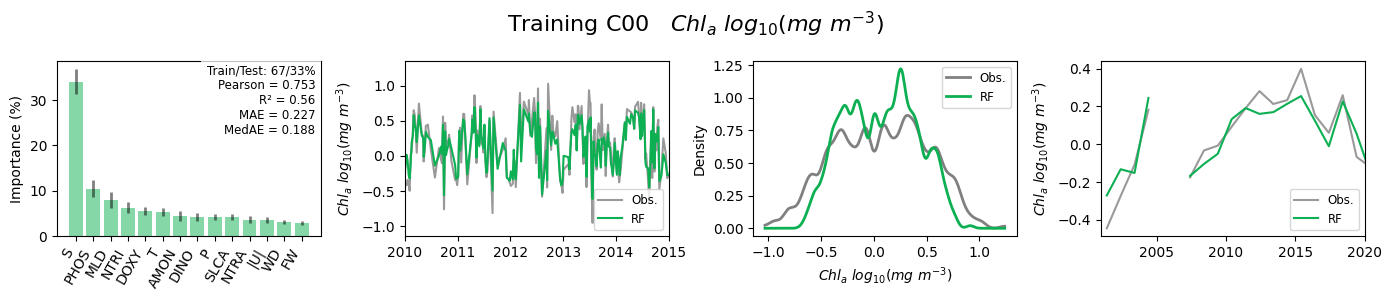

['CORE_run_0_C00_log10(CHL)_14FEATS_PEAR753_MAE227_FULL.png']

In [28]:
np.NaN = np.nan
fig_files = []

for i in range(len(R)):
    fig_files.append(plot_rf_run(R, i, experience, fig_export_dir="", dpi=600))

fig_files

In [29]:
from google.colab import files
for f in fig_files:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_run(R, i, experience, fig_export_dir="", dpi=600):
    row = R.iloc[i]
    fs = 18
    trnm = row["Training"]
    label_stri = row["Target"]
    training_sub_list = row["Predictors"]
    test_size = row["%ForTest"]

    proj = np.asarray(row["Projection"])
    y_all = np.asarray(row["ObsAll"])
    dt = np.asarray(row["Dates"]).astype("datetime64")
    years = np.asarray(row["Years"])

    impor = np.asarray(row["Importances"])
    impor_std = np.asarray(row["Importances STD"])
    names = np.asarray(row["ImporNames"])

    m1 = row["Pearson"]
    m2 = row["p-v"]
    m3 = row["R2"]
    m5 = row["MAE"]
    m6 = row["MEDAE"]

    label_var = row["LabelVar"]
    clr_var = row["Color"]

    period_ia = np.arange(2001, 2020 + 1, 1)
    dt_ia = np.array([datetime(y, 6, 1) for y in period_ia])
    obs_ia = beaning_median(y_all, period_ia, years)
    rfo_ia = beaning_median(proj, period_ia, years)

    out_name = (
        "run_" + str(i) + "_" + trnm + "_" + label_stri + "_" +
        str(len(training_sub_list)) + "FEATS" +
        "_PEAR" + str(int(1000 * np.round(m1, 3))) +
        "_MAE" + str(int(1000 * np.round(m5, 3)))
    )

    fig_filename = experience + "_" + out_name + ".png"

    fig, axs = plt.subplots(1, 3, figsize=(10, 3))####-----------

    ax = axs[0]
    x = np.arange(len(impor))
    ax.bar(x, impor, color=clr_var, alpha=.5)
    ax.errorbar(x, impor, yerr=impor_std, fmt="none", ecolor="k", lw=2, alpha=.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10, rotation=60, ha="right")
    ax.set_ylabel("Importance (%)")
    #ax.set_title("a) Importances", loc="left",fontsize=fs)

    score_txt = (
        f"Train/Test: {round(100 * (1 - test_size))}/{round(100 * test_size)}%\n"
        f"Pearson = {np.round(m1, 3)}\n"
        #f"p = {np.round(m2, 3)}\n"
        f"R² = {np.round(m3, 3)}\n"
        f"MAE = {np.round(m5, 3)}\n"
        f"MedAE = {np.round(m6, 3)}"
    )
    ax.text(
        0.98, 0.98, score_txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.75)
    )

    ax = axs[1]
    ax.plot(dt, y_all, "-", color="gray", alpha=.8, label="Obs.")
    ax.plot(dt, proj, "-", color=clr_var, alpha=1, label="RF")
    ax.set_xlim(datetime(2010, 1, 1), datetime(2015, 1, 1))
    ax.set_ylabel(label_var)
    #ax.set_title("b) Weekly time series", loc="left",fontsize=fs)
    ax.legend(fontsize=8.5)

    from scipy.stats import gaussian_kde

    #ax = axs[2]

    #yy_obs = y_all[np.isfinite(y_all)]
    #yy_rf = proj[np.isfinite(proj)]

    #xmin = np.nanmin([yy_obs.min(), yy_rf.min()])
    #xmax = np.nanmax([yy_obs.max(), yy_rf.max()])
    #xx = np.linspace(xmin, xmax, 300)

    #bw = 0.1

    #if len(yy_obs) > 2 and np.nanstd(yy_obs) > 0:
    #    kde_obs = gaussian_kde(yy_obs, bw_method=bw)
    #    ax.plot(xx, kde_obs(xx), color="gray", lw=2, label="Obs.")

    #if len(yy_rf) > 2 and np.nanstd(yy_rf) > 0:
    #    kde_rf = gaussian_kde(yy_rf, bw_method=bw)
    #    ax.plot(xx, kde_rf(xx), color=clr_var, lw=2, label="RF")

    #ax.set_xlabel(label_var)
    #ax.set_ylabel("Density")
    ##ax.set_title("c) PDFs", loc="left")
    #ax.legend(fontsize=8.5)

    from matplotlib.dates import YearLocator, DateFormatter

    ax = axs[2]
    ax.plot(dt_ia, obs_ia, "-", color="gray", alpha=.8, lw=1.5, label="Obs.")
    ax.plot(dt_ia, rfo_ia, "-", color=clr_var, alpha=1, lw=1.5, label="RF")
    ax.set_xlim(datetime(2001, 1, 1), datetime(2020, 1, 1))
    #ax.set_ylabel(label_var)
    #ax.set_title("d) Interannual", loc="left")
    ax.legend(fontsize=8.5)

    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    fig.suptitle("Training " + trnm + "   " + label_var, fontsize=16)
    fig.tight_layout(pad=1)

    if fig_export_dir:
        fig.savefig(fig_export_dir + "runs/" + fig_filename, dpi=dpi, bbox_inches="tight")
    else:
        fig.savefig(fig_filename, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig_filename

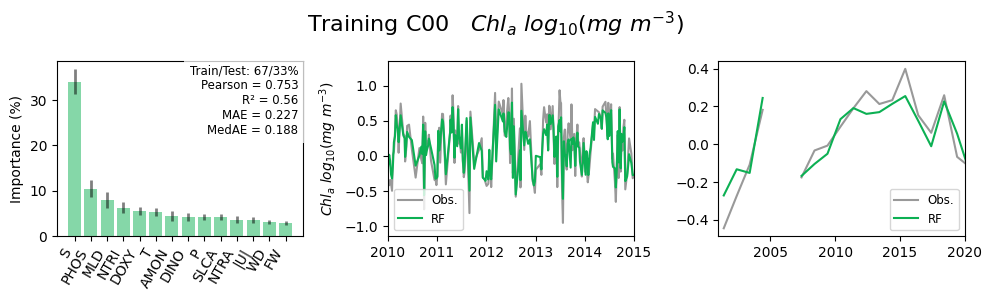

['CORE_run_0_C00_log10(CHL)_14FEATS_PEAR753_MAE227.png']

In [31]:
np.NaN = np.nan
fig_files = []

for i in range(len(R)):
    fig_files.append(plot_rf_run(R, i, experience, fig_export_dir="", dpi=600))

fig_files

In [32]:
from google.colab import files
for f in fig_files:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>